# Analisis Exploratorio de Datos (EDA) — Dataset Tox21

Este notebook realiza un analisis exhaustivo del dataset **Tox21** que se utiliza para entrenar
el modelo GNN-GIN de prediccion de toxicidad. El objetivo es entender:

1. **Estructura del dataset**: cuantas moleculas, cuantas tareas, que porcentaje de datos falta
2. **Desbalance de clases**: que tan raros son los compuestos toxicos en cada tarea
3. **Patrones de datos faltantes**: que tareas tienen mas NaN y si hay patrones sistematicos
4. **Relaciones entre tareas**: que vias de toxicidad se activan juntas
5. **Propiedades moleculares**: tamano, peso, tipos de atomos, grupos funcionales
6. **Diversidad de scaffolds**: que tan diverso es el espacio quimico cubierto
7. **Calidad del split**: si train/val/test son representativos

---

### Dataset Tox21

Tox21 (Toxicology in the 21st Century) es una iniciativa del NIH, EPA y FDA que evalua
~8000 compuestos quimicos en **12 ensayos biologicos** de toxicidad. Cada ensayo mide si
un compuesto activa una diana biologica especifica (receptor nuclear o via de estres).

| Familia | Tareas | Que miden |
|---|---|---|
| **NR** (Nuclear Receptor) | NR-AR, NR-AR-LBD, NR-AhR, NR-Aromatase, NR-ER, NR-ER-LBD, NR-PPAR-gamma | Disrupcion endocrina |
| **SR** (Stress Response) | SR-ARE, SR-AtAD5, SR-HSE, SR-MMP, SR-p53 | Estres celular y genotoxicidad |

## 0. Configuracion e importaciones

In [23]:
import sys
from pathlib import Path

# Agregar la raiz del proyecto al path para importar modulos
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter

# Configuracion global de graficos
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# Directorio para guardar graficos
OUT_DIR = ROOT / "outputs" / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raiz del proyecto: {ROOT}")
print(f"Graficos se guardan en: {OUT_DIR}")

Raiz del proyecto: c:\Users\mateo\Desktop\JIC2026
Graficos se guardan en: c:\Users\mateo\Desktop\JIC2026\outputs\eda


## 1. Carga del dataset

In [24]:
from scripts.prepare_tox21_graphs import _extract_smiles_y_mask
from src.data.tox21_deepchem import load_tox21_raw_scaffold
from src.data.dataset import TASK_NAMES, N_TASKS

# Cargar Tox21 con scaffold split desde DeepChem
print("Descargando/cargando Tox21 desde DeepChem...")
_tasks, splits, _transformers = load_tox21_raw_scaffold()
train_ds, val_ds, test_ds = splits

# Extraer SMILES, etiquetas y mascaras por split
data = {}
for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    smi, y, m = _extract_smiles_y_mask(ds)
    data[name] = {"smiles": smi, "y": y, "mask": m}
    print(f"  {name}: {len(smi)} moleculas")

# Concatenar todo para analisis global
all_smiles = data["train"]["smiles"] + data["val"]["smiles"] + data["test"]["smiles"]
all_y = np.concatenate([data["train"]["y"], data["val"]["y"], data["test"]["y"]])
all_mask = np.concatenate([data["train"]["mask"], data["val"]["mask"], data["test"]["mask"]])
split_labels = (
    ["train"] * len(data["train"]["smiles"])
    + ["val"] * len(data["val"]["smiles"])
    + ["test"] * len(data["test"]["smiles"])
)

n_total = len(all_smiles)
print(f"\nTotal: {n_total} moleculas, {N_TASKS} tareas")

Descargando/cargando Tox21 desde DeepChem...
  train: 6258 moleculas
  val: 782 moleculas
  test: 783 moleculas

Total: 7823 moleculas, 12 tareas


## 2. Resumen general del dataset

Antes de graficar, veamos las estadisticas basicas en forma de tabla.

In [25]:
# Construir tabla resumen por tarea
resumen_filas = []
for t, name in enumerate(TASK_NAMES):
    validos = all_mask[:, t].astype(bool)
    n_validos = int(validos.sum())
    n_nan = n_total - n_validos
    if n_validos > 0:
        n_pos = int(all_y[validos, t].sum())
        n_neg = n_validos - n_pos
        pct_pos = 100.0 * n_pos / n_validos
        ratio = n_neg / max(n_pos, 1)
    else:
        n_pos, n_neg, pct_pos, ratio = 0, 0, 0.0, 0.0

    familia = "NR (Receptor Nuclear)" if name.startswith("NR") else "SR (Respuesta a Estres)"
    resumen_filas.append({
        "Tarea": name,
        "Familia": familia,
        "Medidos": n_validos,
        "Faltantes (NaN)": n_nan,
        "% NaN": f"{100.0 * n_nan / n_total:.1f}%",
        "Positivos (toxico)": n_pos,
        "Negativos": n_neg,
        "% Positivos": f"{pct_pos:.2f}%",
        "Ratio neg:pos": f"{ratio:.1f}:1",
    })

df_resumen = pd.DataFrame(resumen_filas)
print(f"Dataset Tox21 — {n_total} moleculas x {N_TASKS} tareas\n")
df_resumen

Dataset Tox21 — 7823 moleculas x 12 tareas



,Tarea,Familia,Medidos,Faltantes (NaN),% NaN,Positivos (toxico),Negativos,% Positivos,Ratio neg:pos
0,NR-AR,NR (Receptor Nuclear),7258,565,7.2%,308,6950,4.24%,22.6:1
1,NR-AR-LBD,NR (Receptor Nuclear),6751,1072,13.7%,237,6514,3.51%,27.5:1
2,NR-AhR,NR (Receptor Nuclear),6542,1281,16.4%,768,5774,11.74%,7.5:1
3,NR-Aromatase,NR (Receptor Nuclear),5815,2008,25.7%,300,5515,5.16%,18.4:1
4,NR-ER,NR (Receptor Nuclear),6186,1637,20.9%,791,5395,12.79%,6.8:1
5,NR-ER-LBD,NR (Receptor Nuclear),6948,875,11.2%,349,6599,5.02%,18.9:1
6,NR-PPAR-gamma,NR (Receptor Nuclear),6443,1380,17.6%,186,6257,2.89%,33.6:1
7,SR-ARE,SR (Respuesta a Estres),5825,1998,25.5%,942,4883,16.17%,5.2:1
8,SR-AtAD5,SR (Respuesta a Estres),7065,758,9.7%,264,6801,3.74%,25.8:1
9,SR-HSE,SR (Respuesta a Estres),6460,1363,17.4%,372,6088,5.76%,16.4:1


### Observaciones clave de la tabla

- Las tareas NR (receptores nucleares) suelen tener **menos positivos** que las SR (estres)
- Hay un desbalance severo: la mayoria de tareas tienen **<10% de positivos**
- El porcentaje de datos faltantes varia significativamente entre tareas
- Estos factores justifican el uso de `pos_weight` en la funcion de perdida y `MaskedBCELoss`

## 3. Distribucion de clases (desbalance)

El desbalance de clases es critico: si una tarea tiene 5% de positivos, un modelo que
siempre predice "no toxico" ya tiene 95% de accuracy. Por eso usamos **AUC-ROC** en vez
de accuracy, y aplicamos **pos_weight** para penalizar mas los falsos negativos.

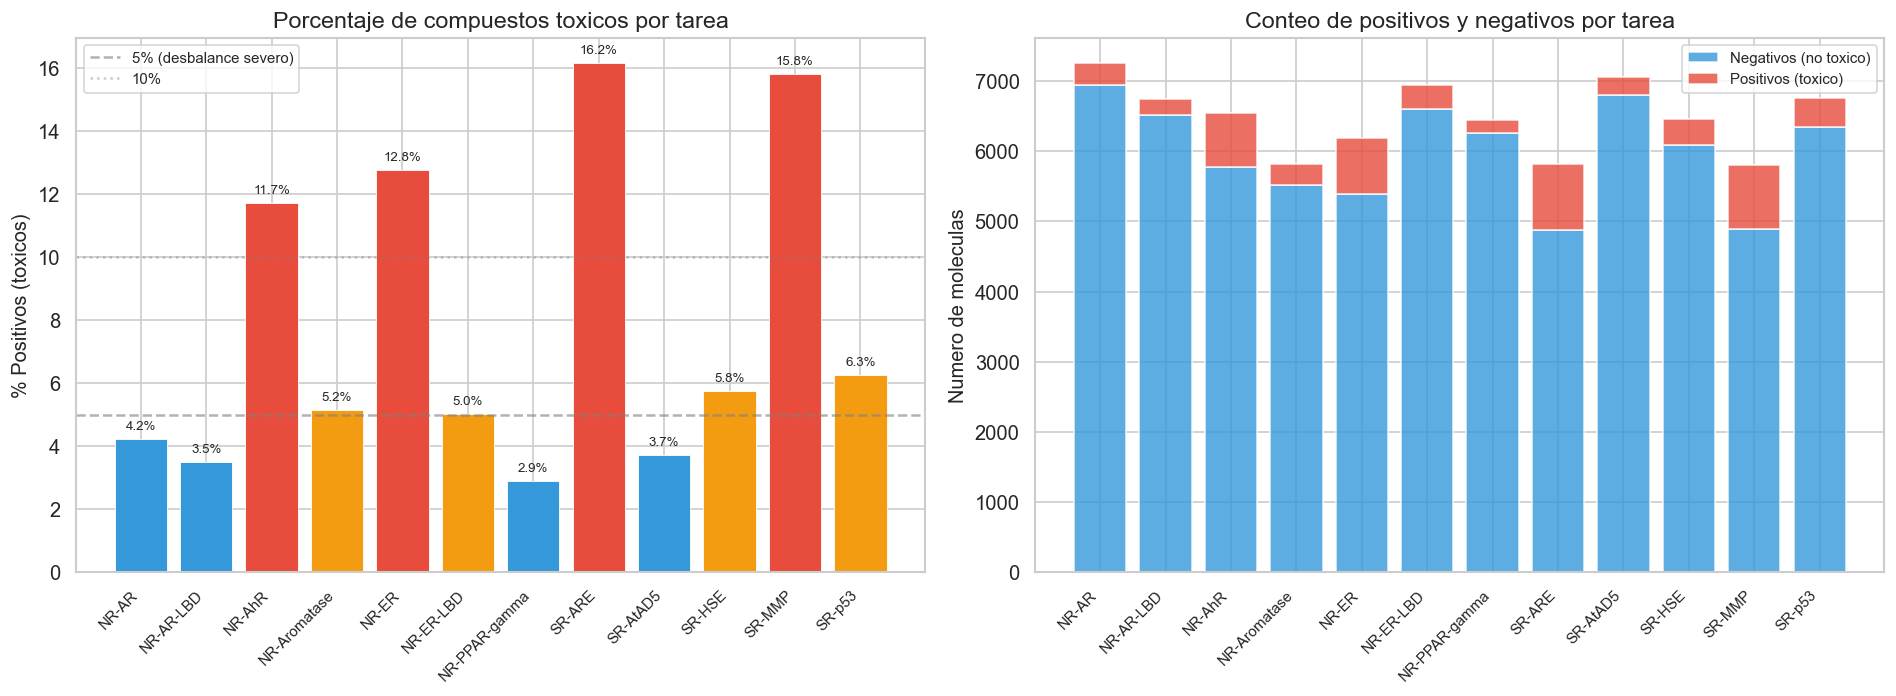


pos_weight sugerido por tarea (neg/pos):
  NR-AR             pos_weight = 22.6
  NR-AR-LBD         pos_weight = 27.5
  NR-AhR            pos_weight = 7.5
  NR-Aromatase      pos_weight = 18.4
  NR-ER             pos_weight = 6.8
  NR-ER-LBD         pos_weight = 18.9
  NR-PPAR-gamma     pos_weight = 33.6
  SR-ARE            pos_weight = 5.2
  SR-AtAD5          pos_weight = 25.8
  SR-HSE            pos_weight = 16.4
  SR-MMP            pos_weight = 5.3
  SR-p53            pos_weight = 15.0


In [26]:
# Calcular porcentaje de positivos por tarea
pct_pos = []
n_pos_list = []
n_neg_list = []
for t in range(N_TASKS):
    validos = all_mask[:, t].astype(bool)
    n_v = validos.sum()
    positivos = all_y[validos, t].sum() if n_v > 0 else 0
    negativos = n_v - positivos
    pct = 100.0 * positivos / n_v if n_v > 0 else 0
    pct_pos.append(pct)
    n_pos_list.append(int(positivos))
    n_neg_list.append(int(negativos))

df_clases = pd.DataFrame({
    "Tarea": TASK_NAMES,
    "Positivos": n_pos_list,
    "Negativos": n_neg_list,
    "% Positivos": pct_pos,
})

# Grafico de barras apiladas: positivos vs negativos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: porcentaje de positivos
colores = ["#e74c3c" if p > 10 else "#f39c12" if p > 5 else "#3498db" for p in pct_pos]
bars = axes[0].bar(range(N_TASKS), pct_pos, color=colores, edgecolor="white", linewidth=0.5)
axes[0].set_xticks(range(N_TASKS))
axes[0].set_xticklabels(TASK_NAMES, rotation=45, ha="right", fontsize=9)
axes[0].set_ylabel("% Positivos (toxicos)")
axes[0].set_title("Porcentaje de compuestos toxicos por tarea")
axes[0].axhline(y=5, color="gray", linestyle="--", alpha=0.6, label="5% (desbalance severo)")
axes[0].axhline(y=10, color="gray", linestyle=":", alpha=0.4, label="10%")
axes[0].legend(fontsize=9)
for bar, val in zip(bars, pct_pos):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", fontsize=8)

# Panel derecho: conteos absolutos apilados
x_pos = np.arange(N_TASKS)
axes[1].bar(x_pos, n_neg_list, label="Negativos (no toxico)", color="#3498db", alpha=0.8)
axes[1].bar(x_pos, n_pos_list, bottom=n_neg_list, label="Positivos (toxico)", color="#e74c3c", alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(TASK_NAMES, rotation=45, ha="right", fontsize=9)
axes[1].set_ylabel("Numero de moleculas")
axes[1].set_title("Conteo de positivos y negativos por tarea")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "01_distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()

print("\npos_weight sugerido por tarea (neg/pos):")
for t, name in enumerate(TASK_NAMES):
    w = n_neg_list[t] / max(n_pos_list[t], 1)
    print(f"  {name:16s}  pos_weight = {w:.1f}")

## 4. Analisis de datos faltantes (NaN)

Tox21 tiene muchos datos faltantes porque no todos los compuestos fueron evaluados en
todos los ensayos. Esto requiere una **mascara** durante el entrenamiento (`MaskedBCELoss`)
para no penalizar predicciones en posiciones sin medicion.

Aqui analizamos:
- Cuanto falta por tarea
- Patron de faltantes: hay moleculas sin ninguna medicion? hay tareas casi vacias?
- Correlacion entre patrones de faltantes (si falta NR-AR, tambien falta NR-AR-LBD?)

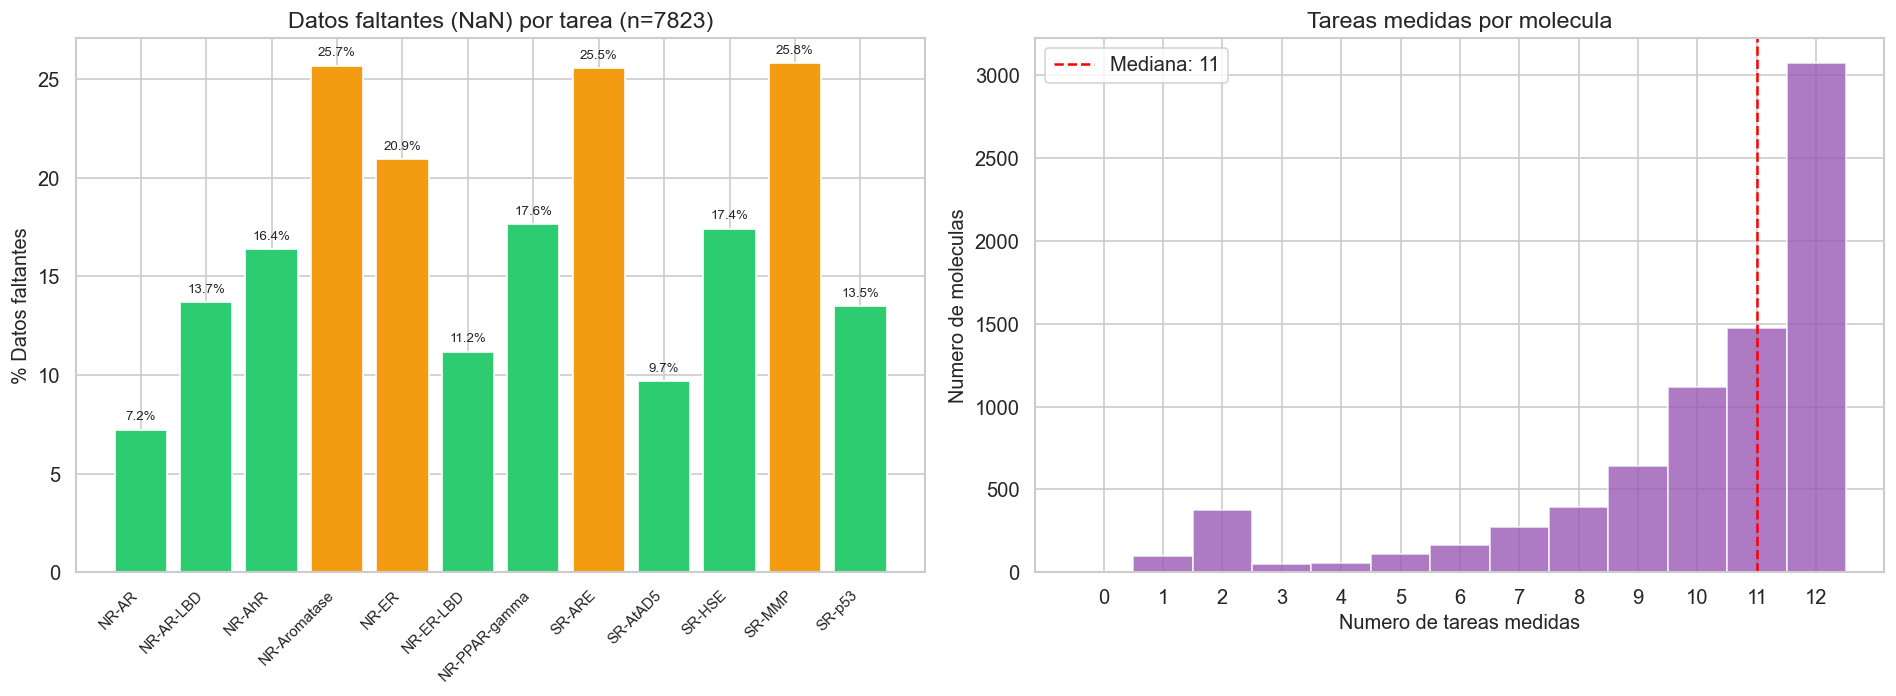

Moleculas con todas las tareas medidas: 3074
Moleculas sin ninguna medicion: 0
Mediana de tareas medidas: 11


In [27]:
# Porcentaje de NaN por tarea
pct_nan = [100.0 * (1 - all_mask[:, t].mean()) for t in range(N_TASKS)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: barras de % NaN
colores_nan = ["#e74c3c" if p > 50 else "#f39c12" if p > 20 else "#2ecc71" for p in pct_nan]
bars = axes[0].bar(range(N_TASKS), pct_nan, color=colores_nan, edgecolor="white")
axes[0].set_xticks(range(N_TASKS))
axes[0].set_xticklabels(TASK_NAMES, rotation=45, ha="right", fontsize=9)
axes[0].set_ylabel("% Datos faltantes")
axes[0].set_title(f"Datos faltantes (NaN) por tarea (n={n_total})")
for bar, val in zip(bars, pct_nan):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", fontsize=8)

# Panel derecho: distribucion de cuantas tareas medidas tiene cada molecula
tareas_por_mol = all_mask.sum(axis=1)
axes[1].hist(tareas_por_mol, bins=range(0, N_TASKS + 2), color="#9b59b6",
             edgecolor="white", alpha=0.8, align="left")
axes[1].set_xlabel("Numero de tareas medidas")
axes[1].set_ylabel("Numero de moleculas")
axes[1].set_title("Tareas medidas por molecula")
axes[1].set_xticks(range(0, N_TASKS + 1))
axes[1].axvline(np.median(tareas_por_mol), color="red", linestyle="--",
                label=f"Mediana: {np.median(tareas_por_mol):.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "02_datos_faltantes.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Moleculas con todas las tareas medidas: {int((tareas_por_mol == N_TASKS).sum())}")
print(f"Moleculas sin ninguna medicion: {int((tareas_por_mol == 0).sum())}")
print(f"Mediana de tareas medidas: {np.median(tareas_por_mol):.0f}")

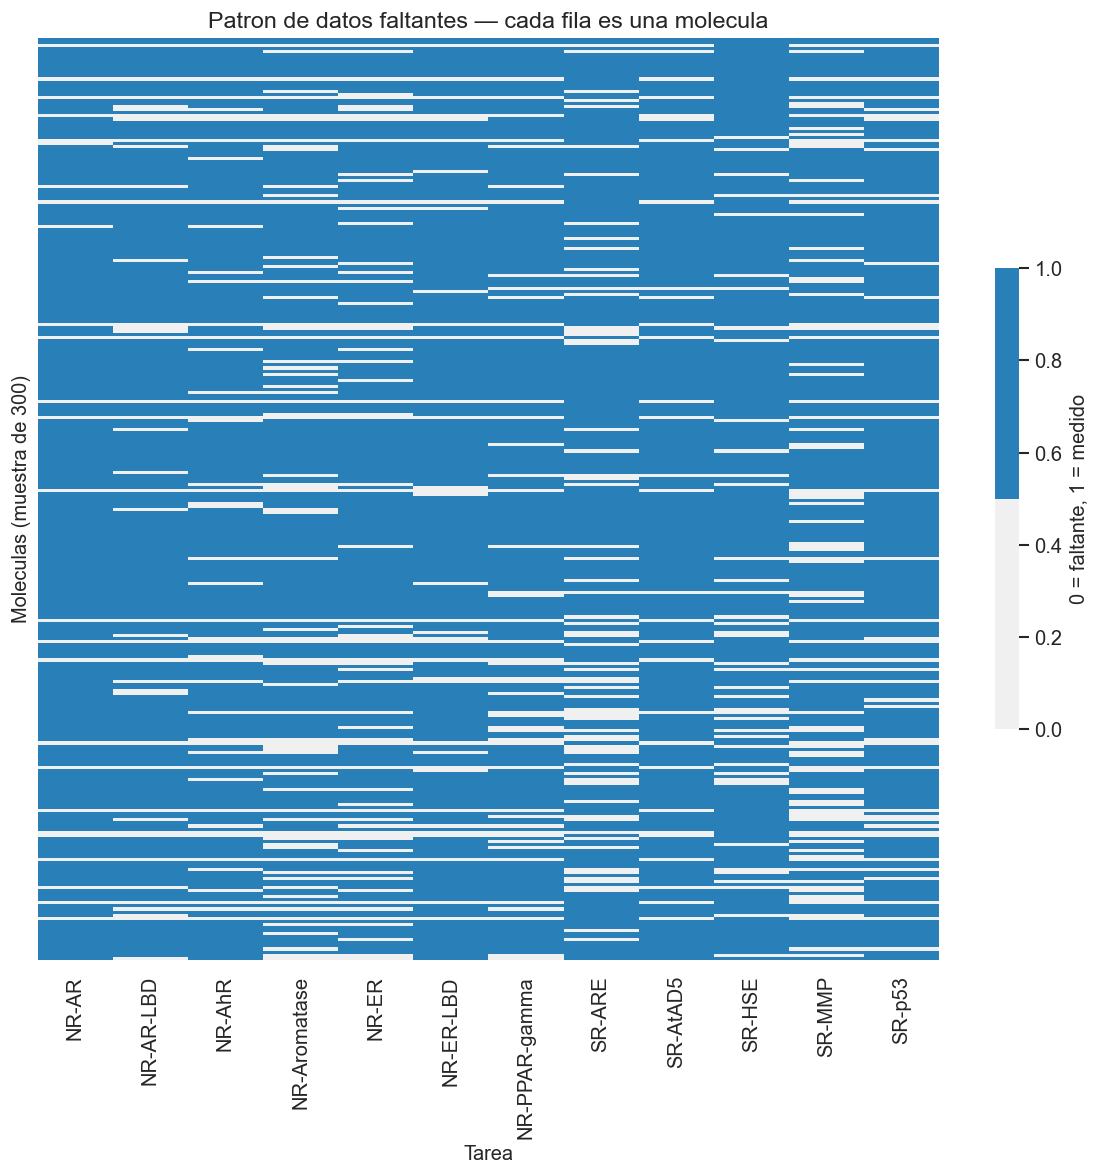

Las columnas con mas blanco son las tareas con mas datos faltantes.
Filas completamente blancas = moleculas sin ninguna medicion.


In [28]:
# Heatmap de patron de datos faltantes (muestra aleatoria de 200 moleculas)
# Cada fila es una molecula, cada columna una tarea
# Azul = medido, Blanco = faltante

rng = np.random.RandomState(42)
n_muestra = min(300, n_total)
idx_muestra = rng.choice(n_total, size=n_muestra, replace=False)
idx_muestra.sort()

mask_muestra = all_mask[idx_muestra, :].astype(int)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    mask_muestra,
    cmap=["#f0f0f0", "#2980b9"],
    cbar_kws={"label": "0 = faltante, 1 = medido", "shrink": 0.5},
    xticklabels=TASK_NAMES,
    yticklabels=False,
    ax=ax,
)
ax.set_xlabel("Tarea")
ax.set_ylabel(f"Moleculas (muestra de {n_muestra})")
ax.set_title("Patron de datos faltantes — cada fila es una molecula")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_patron_faltantes_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Las columnas con mas blanco son las tareas con mas datos faltantes.")
print("Filas completamente blancas = moleculas sin ninguna medicion.")

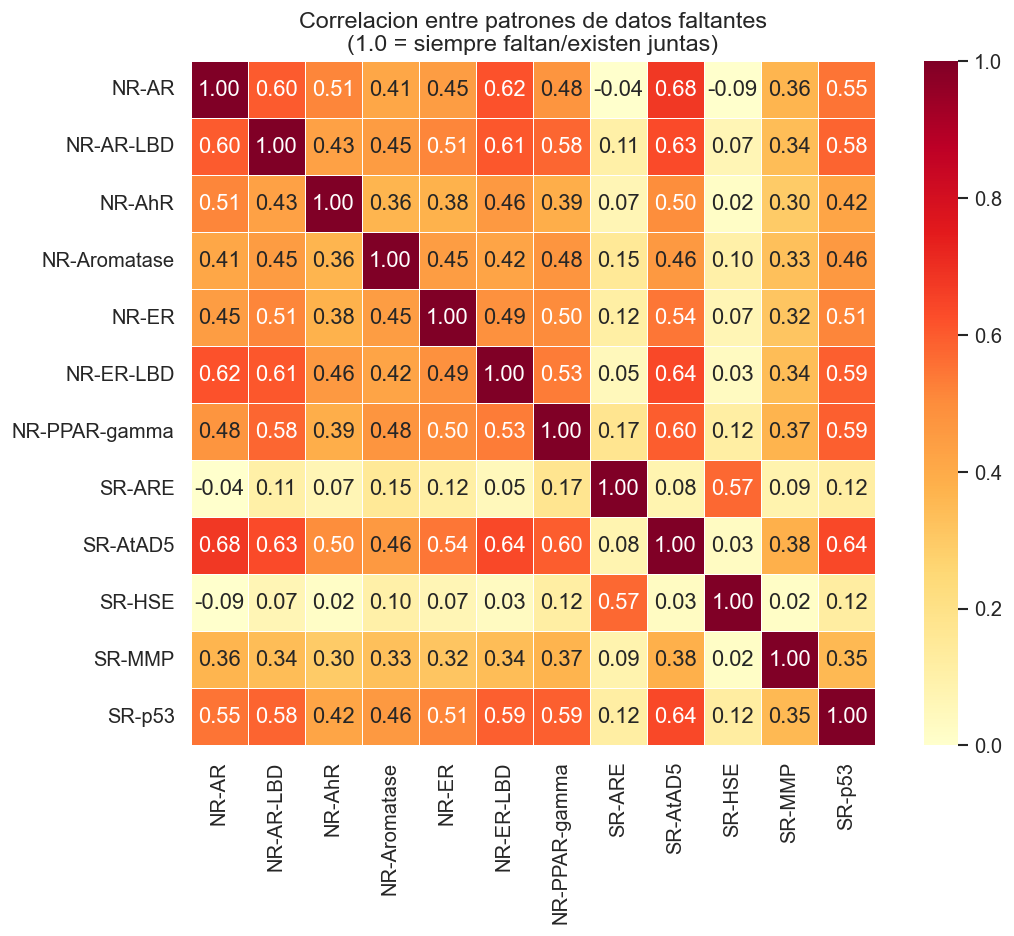

Valores altos indican que esas tareas se midieron en los mismos ensayos.
Valores bajos indican que se midieron de forma independiente.


In [29]:
# Correlacion entre patrones de NaN
# Si falta una tarea, suele faltar otra? (indica que se midieron juntas)

df_mask = pd.DataFrame(all_mask.astype(int), columns=TASK_NAMES)
corr_mask = df_mask.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_mask,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlacion entre patrones de datos faltantes\n(1.0 = siempre faltan/existen juntas)")
plt.tight_layout()
plt.savefig(OUT_DIR / "04_correlacion_faltantes.png", dpi=150, bbox_inches="tight")
plt.show()

print("Valores altos indican que esas tareas se midieron en los mismos ensayos.")
print("Valores bajos indican que se midieron de forma independiente.")

## 5. Analisis multi-etiqueta: co-ocurrencia de toxicidad

Una molecula puede ser toxica en multiples vias simultaneamente. Esto es importante porque:
- Moleculas multi-toxicas son mas peligrosas
- La co-ocurrencia revela mecanismos compartidos (ej: organofosforados activan SR-ARE y SR-MMP)
- Ayuda a entender si el modelo necesita capturar dependencias entre tareas

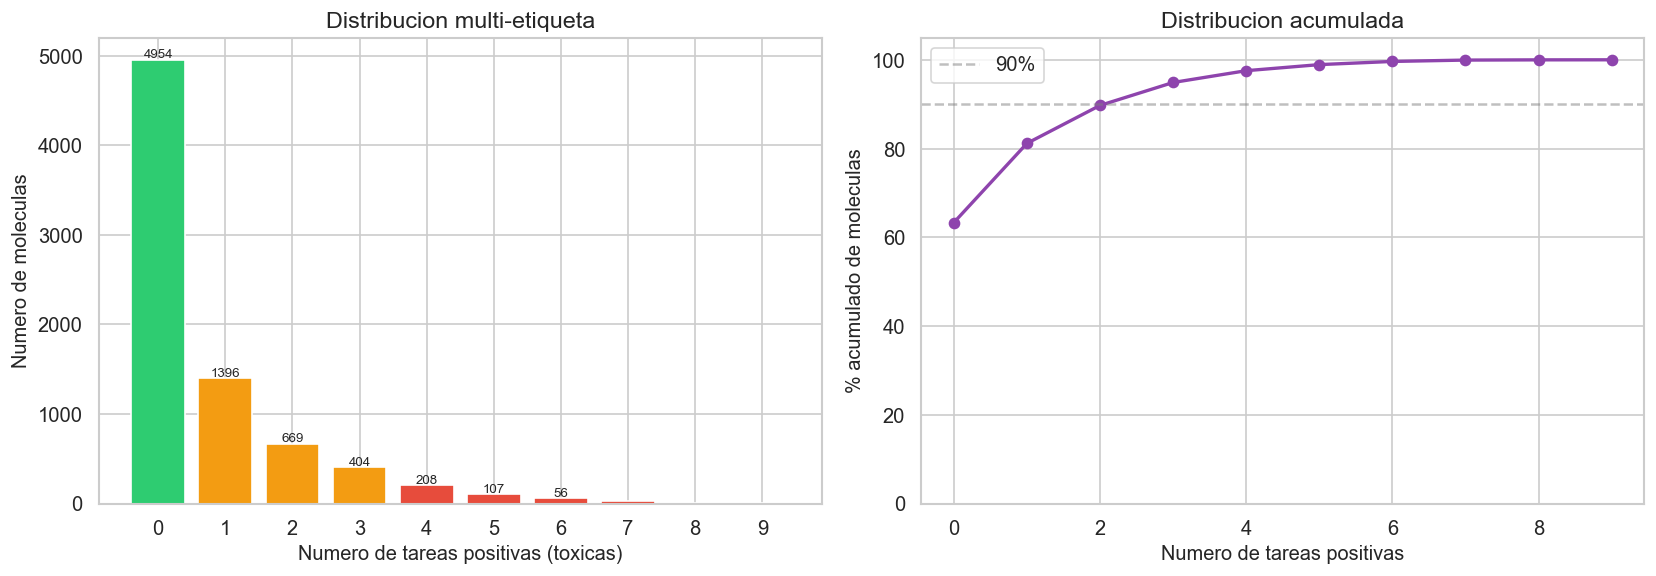

Moleculas sin toxicidad en ninguna tarea: 4954 (63.3%)
Moleculas toxicas en 1+ tareas: 2869
Moleculas toxicas en 5+ tareas: 192


In [30]:
# Cuantas tareas positivas tiene cada molecula (solo entre las medidas)
# Para cada molecula: contar cuantas de sus tareas medidas dieron positivo
y_masked = all_y.copy()
y_masked[~all_mask.astype(bool)] = np.nan

n_positivas_por_mol = np.nansum(y_masked, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: histograma
conteo = Counter(n_positivas_por_mol.astype(int))
x_vals = sorted(conteo.keys())
y_vals = [conteo[x] for x in x_vals]
colores_multi = ["#2ecc71" if x == 0 else "#f39c12" if x <= 3 else "#e74c3c" for x in x_vals]

axes[0].bar(x_vals, y_vals, color=colores_multi, edgecolor="white")
axes[0].set_xlabel("Numero de tareas positivas (toxicas)")
axes[0].set_ylabel("Numero de moleculas")
axes[0].set_title("Distribucion multi-etiqueta")
axes[0].set_xticks(range(0, max(x_vals) + 1))
for x, y_val in zip(x_vals, y_vals):
    if y_val > 50:
        axes[0].text(x, y_val + 20, str(y_val), ha="center", fontsize=8)

# Panel derecho: porcentaje acumulado
total_mol = sum(y_vals)
pct_acum = np.cumsum(y_vals) / total_mol * 100
axes[1].plot(x_vals, pct_acum, "o-", color="#8e44ad", linewidth=2, markersize=6)
axes[1].set_xlabel("Numero de tareas positivas")
axes[1].set_ylabel("% acumulado de moleculas")
axes[1].set_title("Distribucion acumulada")
axes[1].axhline(y=90, color="gray", linestyle="--", alpha=0.5, label="90%")
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig(OUT_DIR / "05_multi_etiqueta.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Moleculas sin toxicidad en ninguna tarea: {conteo.get(0, 0)} ({100*conteo.get(0,0)/total_mol:.1f}%)")
print(f"Moleculas toxicas en 1+ tareas: {total_mol - conteo.get(0, 0)}")
print(f"Moleculas toxicas en 5+ tareas: {sum(v for k,v in conteo.items() if k >= 5)}")

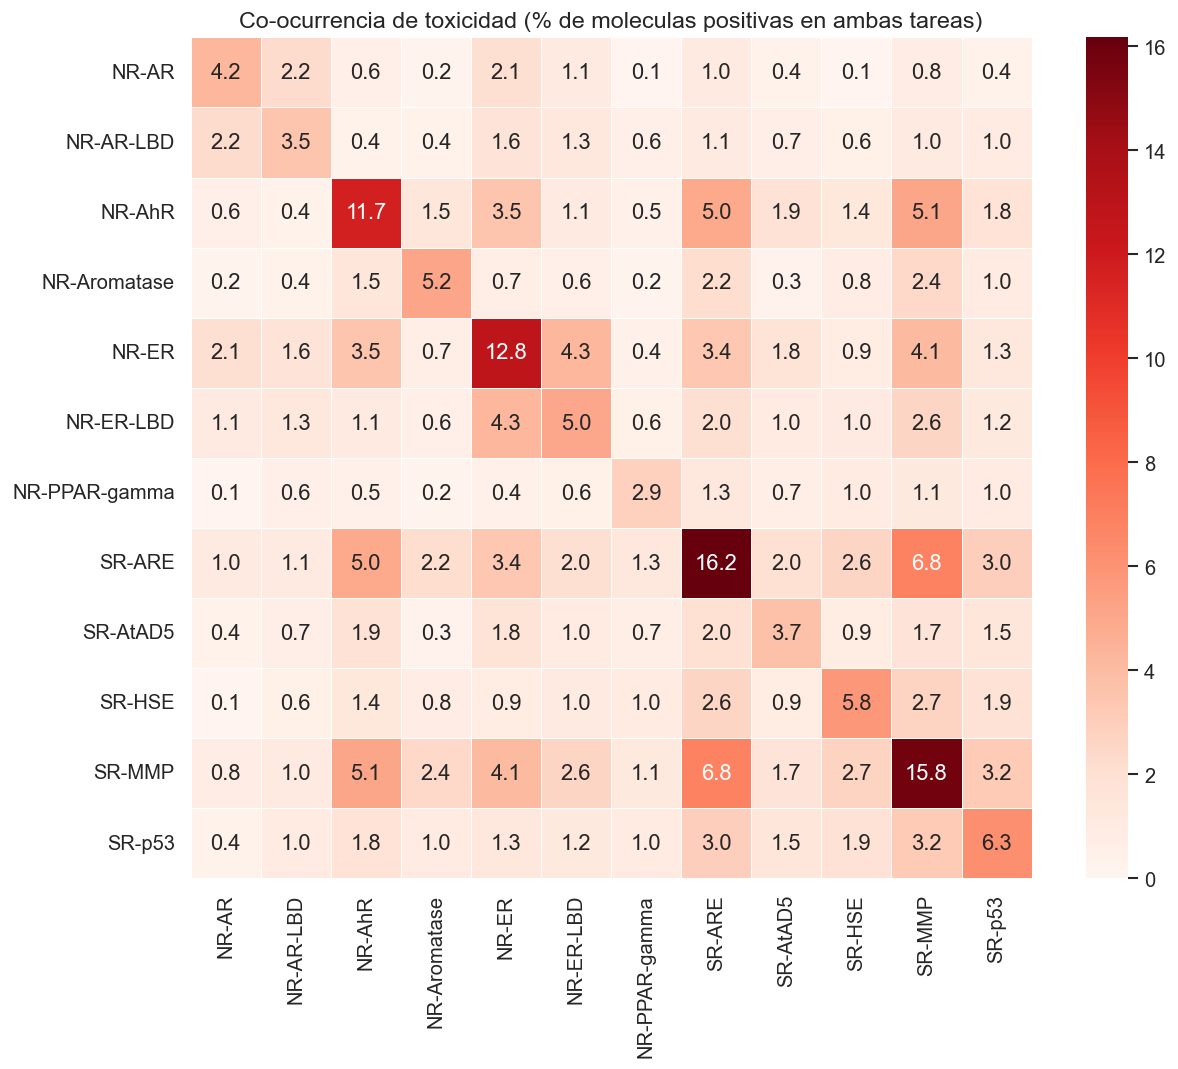

Los valores en la diagonal = % de positivos por tarea (coincide con seccion 3).
Valores altos fuera de la diagonal = tareas que se activan juntas.


In [31]:
# Matriz de co-ocurrencia: si una molecula es toxica en tarea A y tarea B
# Solo consideramos moleculas medidas en ambas tareas

cooc = np.zeros((N_TASKS, N_TASKS))
for i in range(N_TASKS):
    for j in range(N_TASKS):
        # Moleculas medidas en ambas tareas
        ambas_medidas = all_mask[:, i].astype(bool) & all_mask[:, j].astype(bool)
        if ambas_medidas.sum() == 0:
            continue
        # De las medidas en ambas, cuantas son positivas en ambas
        ambas_pos = all_y[ambas_medidas, i] * all_y[ambas_medidas, j]
        cooc[i, j] = ambas_pos.sum() / ambas_medidas.sum() * 100

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cooc,
    annot=True, fmt=".1f",
    cmap="Reds",
    xticklabels=TASK_NAMES,
    yticklabels=TASK_NAMES,
    square=True,
    linewidths=0.5,
    ax=ax,
    vmin=0,
)
ax.set_title("Co-ocurrencia de toxicidad (% de moleculas positivas en ambas tareas)")
plt.tight_layout()
plt.savefig(OUT_DIR / "06_coocurrencia_toxicidad.png", dpi=150, bbox_inches="tight")
plt.show()

print("Los valores en la diagonal = % de positivos por tarea (coincide con seccion 3).")
print("Valores altos fuera de la diagonal = tareas que se activan juntas.")

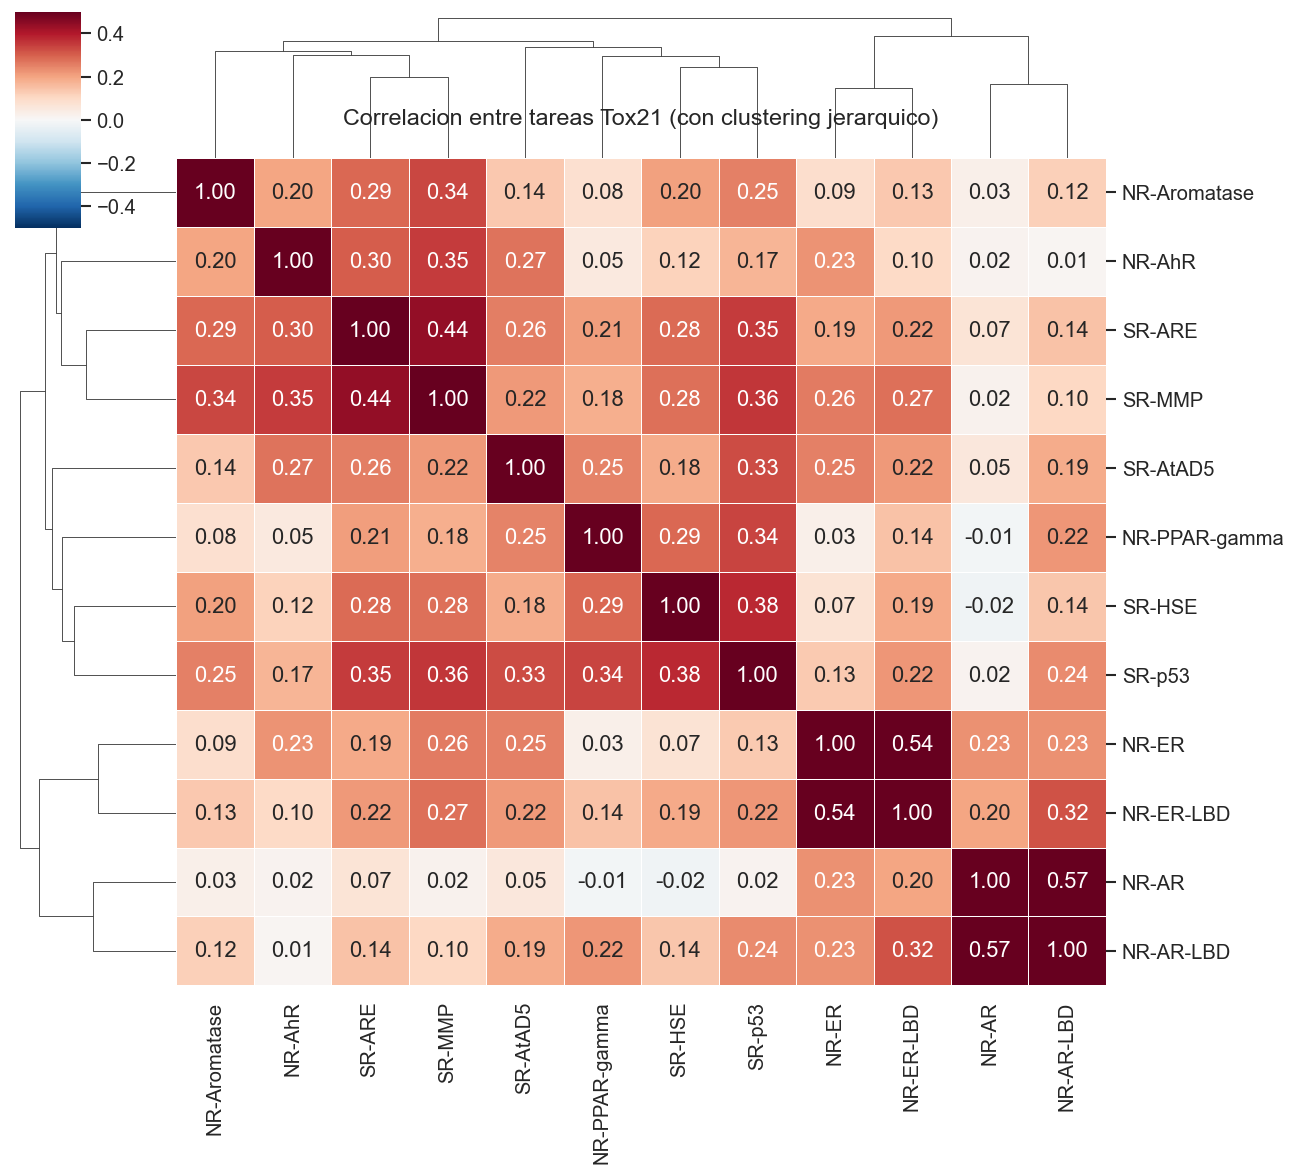

El dendrograma agrupa las tareas que tienden a activarse juntas.
Esperamos ver NR-AR y NR-AR-LBD juntas (misma diana), NR-ER y NR-ER-LBD juntas, etc.


In [32]:
# Correlacion de Pearson entre etiquetas (solo datos medidos)
# Esto captura la relacion LINEAL entre vias de toxicidad

df_y = pd.DataFrame(y_masked, columns=TASK_NAMES)
corr_y = df_y.corr()

# Clustermap con dendrograma para agrupar tareas similares
g = sns.clustermap(
    corr_y,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0,
    vmin=-0.5, vmax=0.5,
    linewidths=0.5,
    figsize=(11, 10),
    dendrogram_ratio=(0.15, 0.15),
)
g.ax_heatmap.set_title("Correlacion entre tareas Tox21 (con clustering jerarquico)", pad=20)
plt.savefig(OUT_DIR / "07_correlacion_tareas_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

print("El dendrograma agrupa las tareas que tienden a activarse juntas.")
print("Esperamos ver NR-AR y NR-AR-LBD juntas (misma diana), NR-ER y NR-ER-LBD juntas, etc.")

## 6. Propiedades moleculares

Analizamos propiedades fisicoquimicas de las moleculas usando RDKit. Esto ayuda a entender
el espacio quimico cubierto por el dataset y detectar moleculas atipicas (outliers).

In [33]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors

# Calcular propiedades moleculares para cada SMILES
props = []
smiles_validos = []
split_validos = []

for i, smi in enumerate(all_smiles):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    smiles_validos.append(smi)
    split_validos.append(split_labels[i])
    props.append({
        "n_atomos": mol.GetNumAtoms(),
        "n_enlaces": mol.GetNumBonds(),
        "peso_molecular": Descriptors.MolWt(mol),
        "logP": Descriptors.MolLogP(mol),
        "n_anillos": rdMolDescriptors.CalcNumRings(mol),
        "n_anillos_aromaticos": rdMolDescriptors.CalcNumAromaticRings(mol),
        "n_H_donors": Lipinski.NumHDonors(mol),
        "n_H_acceptors": Lipinski.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "n_enlaces_rotables": Lipinski.NumRotatableBonds(mol),
    })

df_props = pd.DataFrame(props)
df_props["split"] = split_validos

print(f"Moleculas validas con RDKit: {len(df_props)} de {n_total}")
print(f"\nEstadisticas descriptivas:")
df_props.drop(columns="split").describe().round(1)

[22:49:45] WARNING: not removing hydrogen atom without neighbors


Moleculas validas con RDKit: 7823 de 7823

Estadisticas descriptivas:


,n_atomos,n_enlaces,peso_molecular,logP,n_anillos,n_anillos_aromaticos,n_H_donors,n_H_acceptors,TPSA,n_enlaces_rotables
count,7823.0,7823.0,7823.0,7823.0,7823.0,7823.0,7823.0,7823.0,7823.0,7823.0
mean,18.6,19.3,276.1,2.4,1.8,1.1,1.2,3.5,59.5,4.3
std,11.3,12.5,164.7,2.3,1.7,1.1,1.9,3.1,57.8,4.5
min,1.0,0.0,9.0,-17.4,0.0,0.0,0.0,0.0,0.0,0.0
25%,11.0,11.0,165.2,1.1,1.0,0.0,0.0,2.0,26.3,1.0
50%,16.0,17.0,240.3,2.4,1.0,1.0,1.0,3.0,46.5,3.0
75%,23.0,25.0,343.0,3.7,3.0,2.0,2.0,4.0,77.0,6.0
max,132.0,145.0,1877.7,22.6,30.0,12.0,30.0,46.0,778.0,47.0


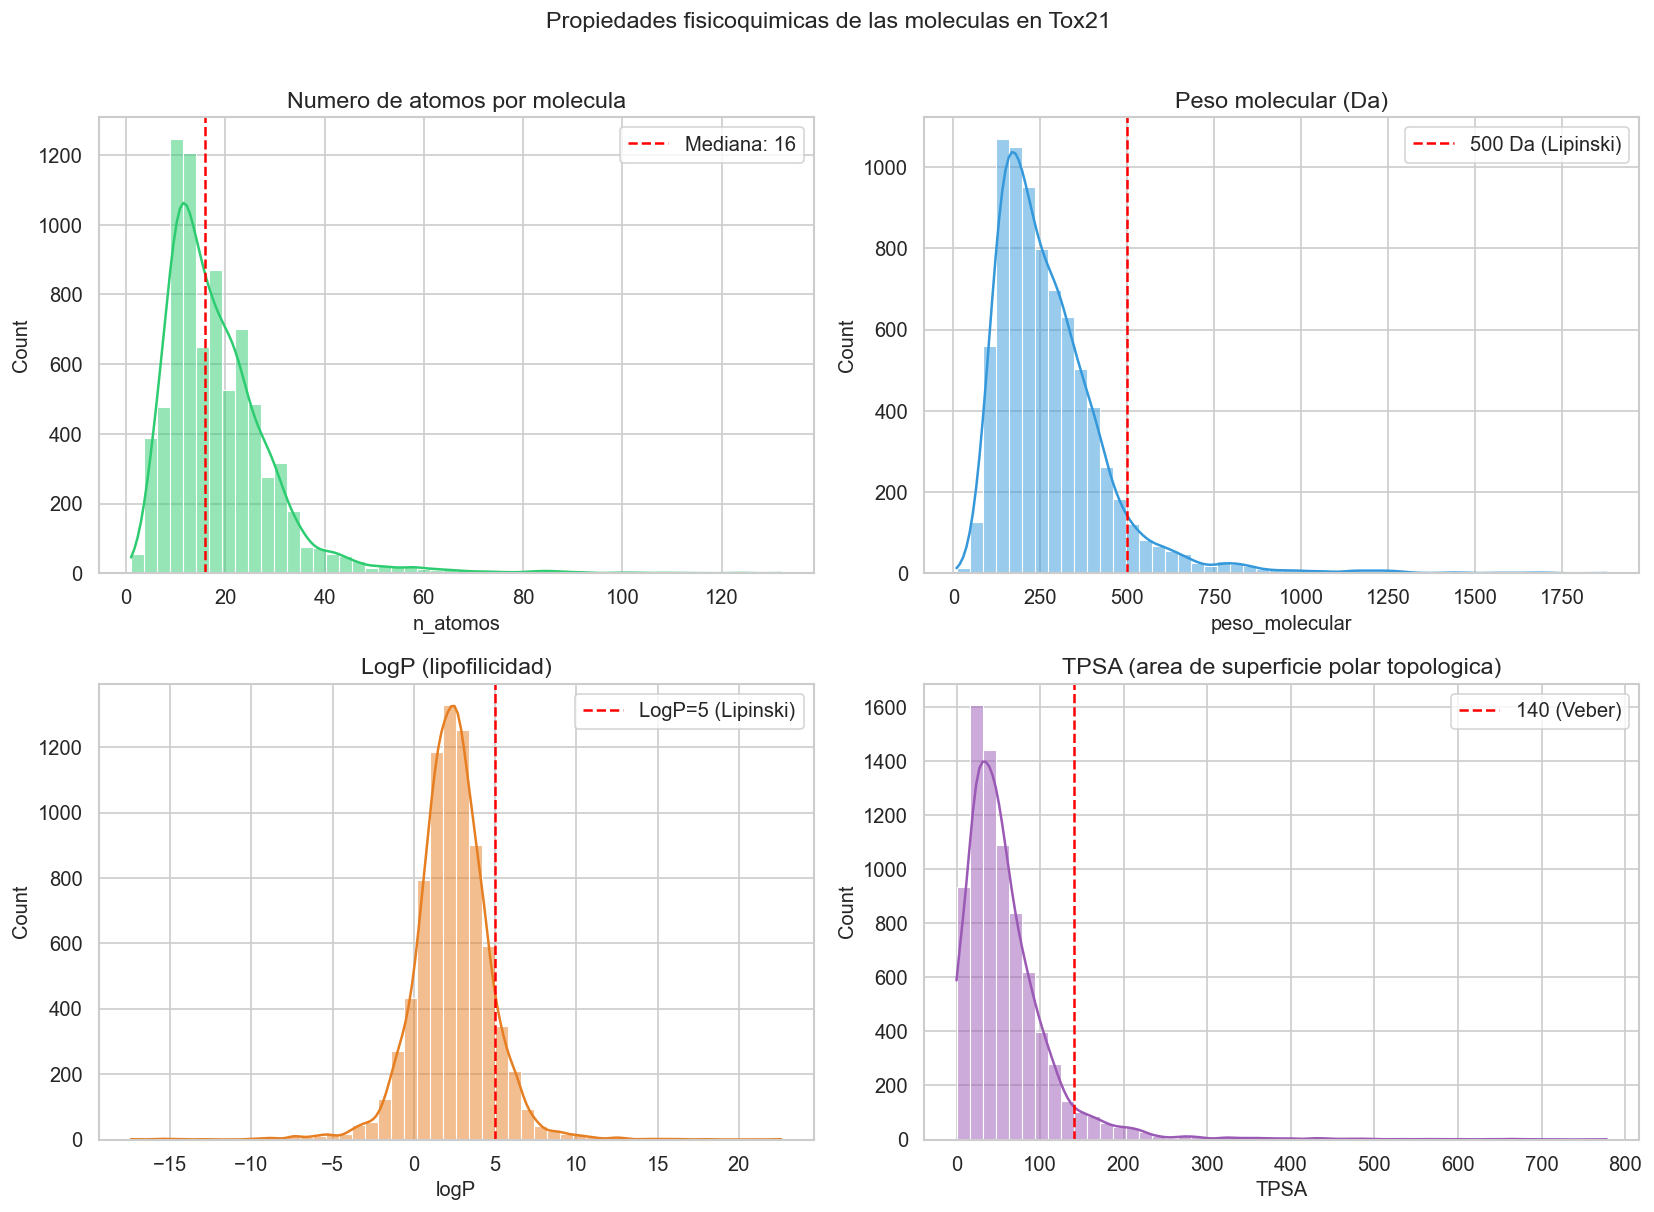

In [34]:
# Distribucion de tamano molecular y peso
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Numero de atomos
sns.histplot(df_props["n_atomos"], bins=50, kde=True, color="#2ecc71", ax=axes[0, 0])
axes[0, 0].axvline(df_props["n_atomos"].median(), color="red", linestyle="--",
                    label=f"Mediana: {df_props['n_atomos'].median():.0f}")
axes[0, 0].set_title("Numero de atomos por molecula")
axes[0, 0].legend()

# Peso molecular
sns.histplot(df_props["peso_molecular"], bins=50, kde=True, color="#3498db", ax=axes[0, 1])
axes[0, 1].axvline(500, color="red", linestyle="--", label="500 Da (Lipinski)")
axes[0, 1].set_title("Peso molecular (Da)")
axes[0, 1].legend()

# LogP (lipofilicidad)
sns.histplot(df_props["logP"], bins=50, kde=True, color="#e67e22", ax=axes[1, 0])
axes[1, 0].axvline(5, color="red", linestyle="--", label="LogP=5 (Lipinski)")
axes[1, 0].set_title("LogP (lipofilicidad)")
axes[1, 0].legend()

# TPSA (area de superficie polar)
sns.histplot(df_props["TPSA"], bins=50, kde=True, color="#9b59b6", ax=axes[1, 1])
axes[1, 1].axvline(140, color="red", linestyle="--", label="140 (Veber)")
axes[1, 1].set_title("TPSA (area de superficie polar topologica)")
axes[1, 1].legend()

plt.suptitle("Propiedades fisicoquimicas de las moleculas en Tox21", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "08_propiedades_moleculares.png", dpi=150, bbox_inches="tight")
plt.show()

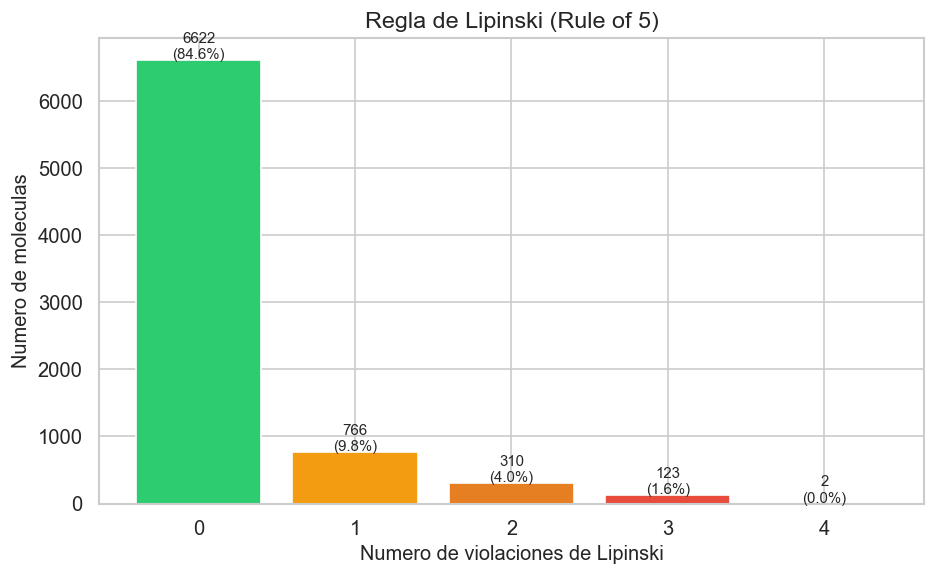

Moleculas 'drug-like' (0 violaciones): 6622 (84.6%)


In [35]:
# Regla de Lipinski (Rule of 5): filtro de drug-likeness
# Una molecula "drug-like" cumple:
#   - Peso molecular < 500
#   - LogP < 5
#   - H-bond donors < 5
#   - H-bond acceptors < 10

violaciones = (
    (df_props["peso_molecular"] > 500).astype(int)
    + (df_props["logP"] > 5).astype(int)
    + (df_props["n_H_donors"] > 5).astype(int)
    + (df_props["n_H_acceptors"] > 10).astype(int)
)

fig, ax = plt.subplots(figsize=(8, 5))
conteo_viol = Counter(violaciones)
x_v = sorted(conteo_viol.keys())
y_v = [conteo_viol[x] for x in x_v]
colores_v = ["#2ecc71", "#f39c12", "#e67e22", "#e74c3c", "#c0392b"]

bars = ax.bar(x_v, y_v, color=[colores_v[min(x, 4)] for x in x_v], edgecolor="white")
ax.set_xlabel("Numero de violaciones de Lipinski")
ax.set_ylabel("Numero de moleculas")
ax.set_title("Regla de Lipinski (Rule of 5)")
ax.set_xticks(range(5))
for bar, val in zip(bars, y_v):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{val}\n({100*val/len(df_props):.1f}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "09_lipinski.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Moleculas 'drug-like' (0 violaciones): {conteo_viol.get(0, 0)} ({100*conteo_viol.get(0,0)/len(df_props):.1f}%)")

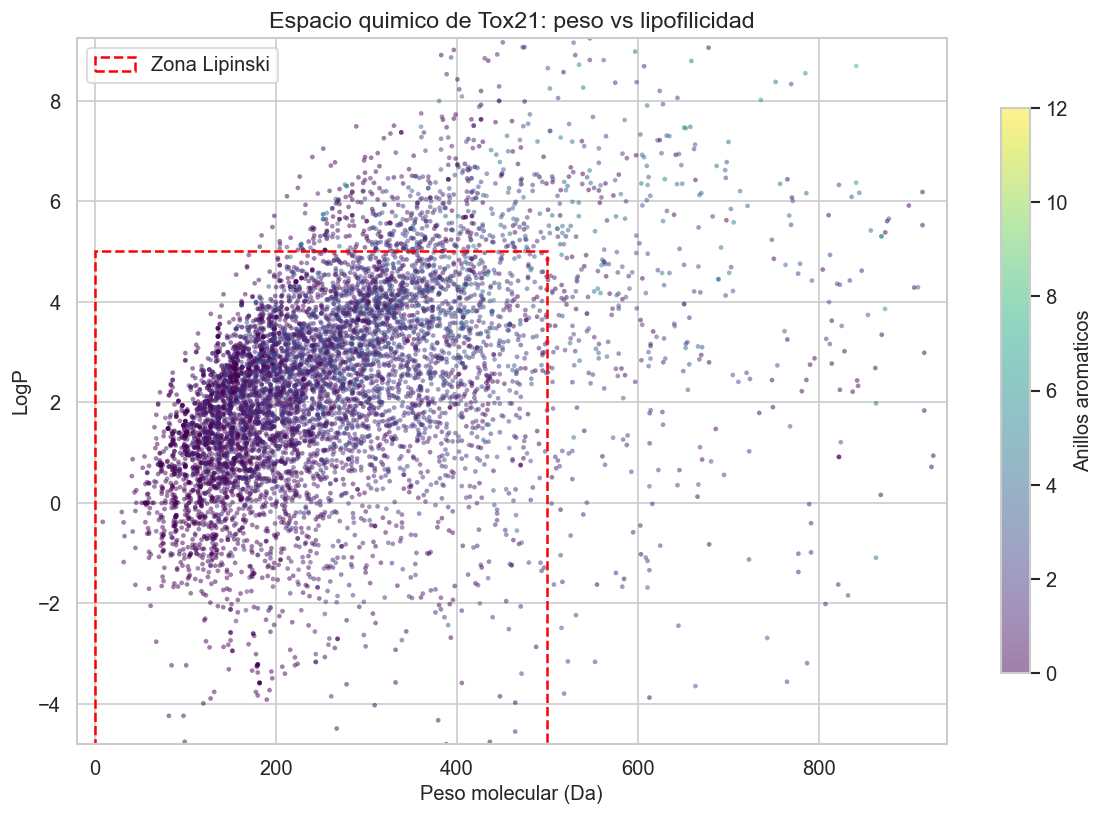

In [36]:
# Scatter: peso molecular vs logP, coloreado por n_anillos_aromaticos
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    df_props["peso_molecular"],
    df_props["logP"],
    c=df_props["n_anillos_aromaticos"],
    cmap="viridis",
    s=8, alpha=0.5,
    edgecolors="none",
)
plt.colorbar(scatter, label="Anillos aromaticos", shrink=0.8)
ax.set_xlabel("Peso molecular (Da)")
ax.set_ylabel("LogP")
ax.set_title("Espacio quimico de Tox21: peso vs lipofilicidad")

# Marcar zona Lipinski
from matplotlib.patches import Rectangle
rect = Rectangle((0, -5), 500, 10, linewidth=1.5, edgecolor="red",
                  facecolor="none", linestyle="--", label="Zona Lipinski")
ax.add_patch(rect)
ax.legend(loc="upper left")
ax.set_xlim(-20, df_props["peso_molecular"].quantile(0.99) + 50)
ax.set_ylim(df_props["logP"].quantile(0.01) - 1, df_props["logP"].quantile(0.99) + 1)

plt.tight_layout()
plt.savefig(OUT_DIR / "10_espacio_quimico.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Tipos de atomos y estructura molecular

Entender la composicion atomica del dataset es importante porque:
- Las features de nodo codifican el tipo de atomo como one-hot
- Atomos raros (I, Br) tendran poca representacion en el entrenamiento
- La distribucion de tipos de enlace afecta las features de arista

[22:49:54] WARNING: not removing hydrogen atom without neighbors


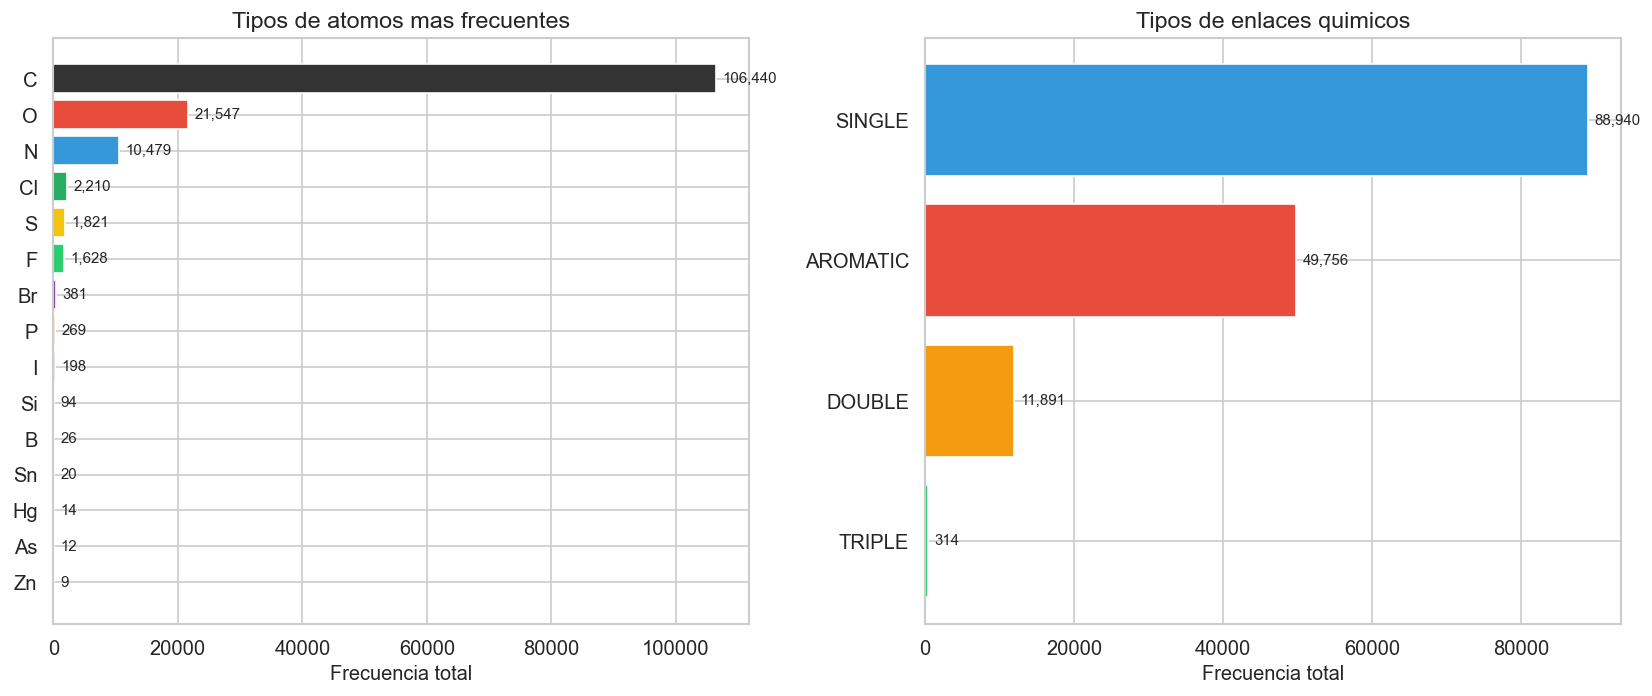


Total de atomos: 145,256
Total de enlaces: 150,901
Tipos de atomos unicos: 50


In [37]:
# Contar tipos de atomos en todo el dataset
atom_counts = Counter()
bond_counts = Counter()

for smi in smiles_validos:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    for atom in mol.GetAtoms():
        atom_counts[atom.GetSymbol()] += 1
    for bond in mol.GetBonds():
        bond_counts[bond.GetBondType().name] += 1

# Top 15 tipos de atomos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Atomos
top_atoms = atom_counts.most_common(15)
atomo_nombres = [a[0] for a in top_atoms]
atomo_conteo = [a[1] for a in top_atoms]
atomo_colores = []
paleta_atomos = {"C": "#333333", "N": "#3498db", "O": "#e74c3c", "S": "#f1c40f",
                 "F": "#2ecc71", "Cl": "#27ae60", "Br": "#8e44ad", "P": "#e67e22",
                 "I": "#9b59b6"}
for a in atomo_nombres:
    atomo_colores.append(paleta_atomos.get(a, "#95a5a6"))

axes[0].barh(range(len(top_atoms)), atomo_conteo, color=atomo_colores, edgecolor="white")
axes[0].set_yticks(range(len(top_atoms)))
axes[0].set_yticklabels(atomo_nombres)
axes[0].set_xlabel("Frecuencia total")
axes[0].set_title("Tipos de atomos mas frecuentes")
axes[0].invert_yaxis()
for i, (nombre, conteo) in enumerate(top_atoms):
    axes[0].text(conteo + max(atomo_conteo) * 0.01, i,
                 f"{conteo:,}", va="center", fontsize=9)

# Enlaces
bond_nombres = [b[0] for b in bond_counts.most_common()]
bond_conteos = [b[1] for b in bond_counts.most_common()]
bond_colores = ["#3498db", "#e74c3c", "#f39c12", "#2ecc71"]

axes[1].barh(range(len(bond_nombres)), bond_conteos,
             color=bond_colores[:len(bond_nombres)], edgecolor="white")
axes[1].set_yticks(range(len(bond_nombres)))
axes[1].set_yticklabels(bond_nombres)
axes[1].set_xlabel("Frecuencia total")
axes[1].set_title("Tipos de enlaces quimicos")
axes[1].invert_yaxis()
for i, (nombre, conteo) in enumerate(bond_counts.most_common()):
    axes[1].text(conteo + max(bond_conteos) * 0.01, i,
                 f"{conteo:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "11_atomos_y_enlaces.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal de atomos: {sum(atom_counts.values()):,}")
print(f"Total de enlaces: {sum(bond_counts.values()):,}")
print(f"Tipos de atomos unicos: {len(atom_counts)}")

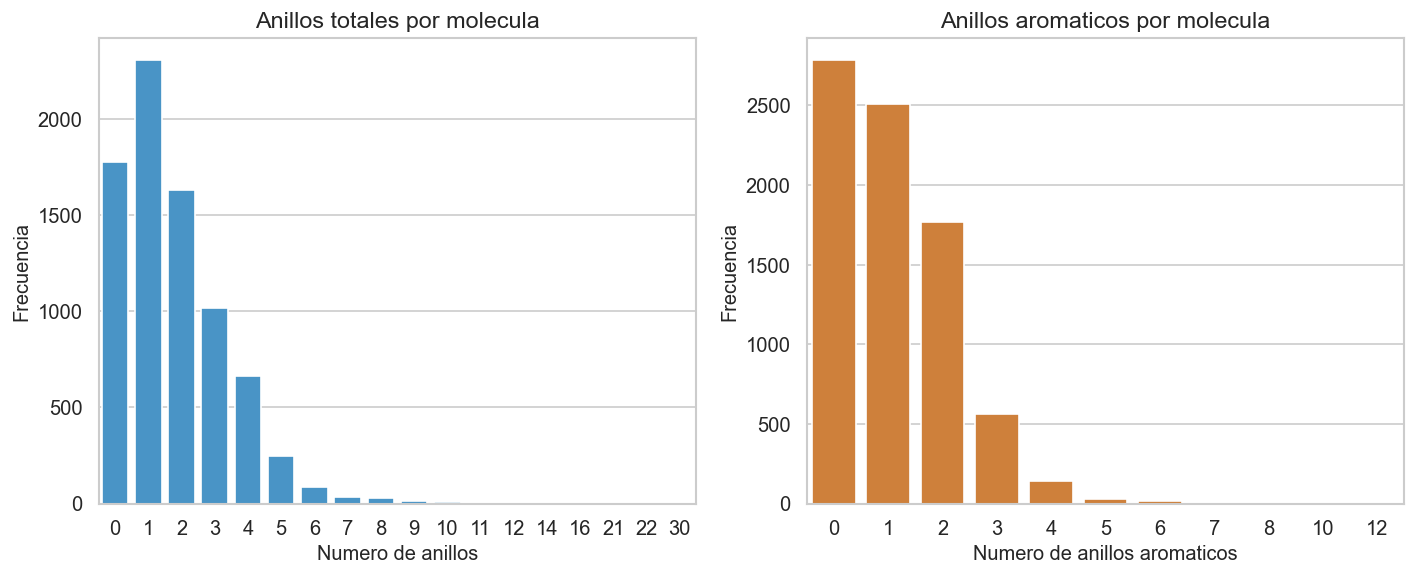

Moleculas sin anillos: 1775 (22.7%)
Moleculas con 3+ anillos aromaticos: 759


In [38]:
# Distribucion de anillos aromaticos y no aromaticos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="n_anillos", data=df_props, color="#3498db", ax=axes[0])
axes[0].set_xlabel("Numero de anillos")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Anillos totales por molecula")

sns.countplot(x="n_anillos_aromaticos", data=df_props, color="#e67e22", ax=axes[1])
axes[1].set_xlabel("Numero de anillos aromaticos")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Anillos aromaticos por molecula")

plt.tight_layout()
plt.savefig(OUT_DIR / "12_anillos.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Moleculas sin anillos: {(df_props['n_anillos'] == 0).sum()} ({100*(df_props['n_anillos']==0).mean():.1f}%)")
print(f"Moleculas con 3+ anillos aromaticos: {(df_props['n_anillos_aromaticos'] >= 3).sum()}")

## 8. Analisis de scaffolds

El scaffold (esqueleto) de Murcko es la estructura central de una molecula, sin las cadenas
laterales. Es la base del **scaffold split** que usamos para dividir el dataset.

Un buen dataset tiene **muchos scaffolds distintos**, lo que indica diversidad quimica.
Si pocos scaffolds dominan, el modelo puede memorizar en vez de generalizar.

In [39]:
from rdkit.Chem.Scaffolds import MurckoScaffold

# Extraer scaffold de cada molecula
scaffolds = []
for smi in smiles_validos:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        scaffolds.append("INVALIDO")
        continue
    try:
        scaf = MurckoScaffold.MurckoScaffoldSmiles(
            mol=mol, includeChirality=False
        )
        scaffolds.append(scaf)
    except Exception:
        scaffolds.append("ERROR")

scaffold_counts = Counter(scaffolds)
n_scaffolds = len(scaffold_counts)

print(f"Moleculas validas: {len(smiles_validos)}")
print(f"Scaffolds unicos: {n_scaffolds}")
print(f"Ratio moleculas/scaffolds: {len(smiles_validos)/n_scaffolds:.1f}")
print(f"\nTop 15 scaffolds mas frecuentes:")
for i, (scaf, count) in enumerate(scaffold_counts.most_common(15), 1):
    pct = 100 * count / len(smiles_validos)
    print(f"  {i:2d}. {scaf[:60]:60s}  n={count}  ({pct:.1f}%)")

[22:49:58] WARNING: not removing hydrogen atom without neighbors


Moleculas validas: 7823
Scaffolds unicos: 2325
Ratio moleculas/scaffolds: 3.4

Top 15 scaffolds mas frecuentes:
   1.                                                               n=1775  (22.7%)
   2. c1ccccc1                                                      n=1474  (18.8%)
   3. c1ccncc1                                                      n=89  (1.1%)
   4. c1ccc(Cc2ccccc2)cc1                                           n=83  (1.1%)
   5. c1ccc2ccccc2c1                                                n=69  (0.9%)
   6. C1CCCCC1                                                      n=63  (0.8%)
   7. c1c[nH+]c[nH]1                                                n=48  (0.6%)
   8. c1ccc(Oc2ccccc2)cc1                                           n=45  (0.6%)
   9. O=C1C=C2CCC3C4CCCC4CCC3C2CC1                                  n=43  (0.5%)
  10. O=C1C=CC2C(=C1)CCC1C3CCCC3CCC21                               n=41  (0.5%)
  11. c1ccc(-c2ccccc2)cc1                                           n=40

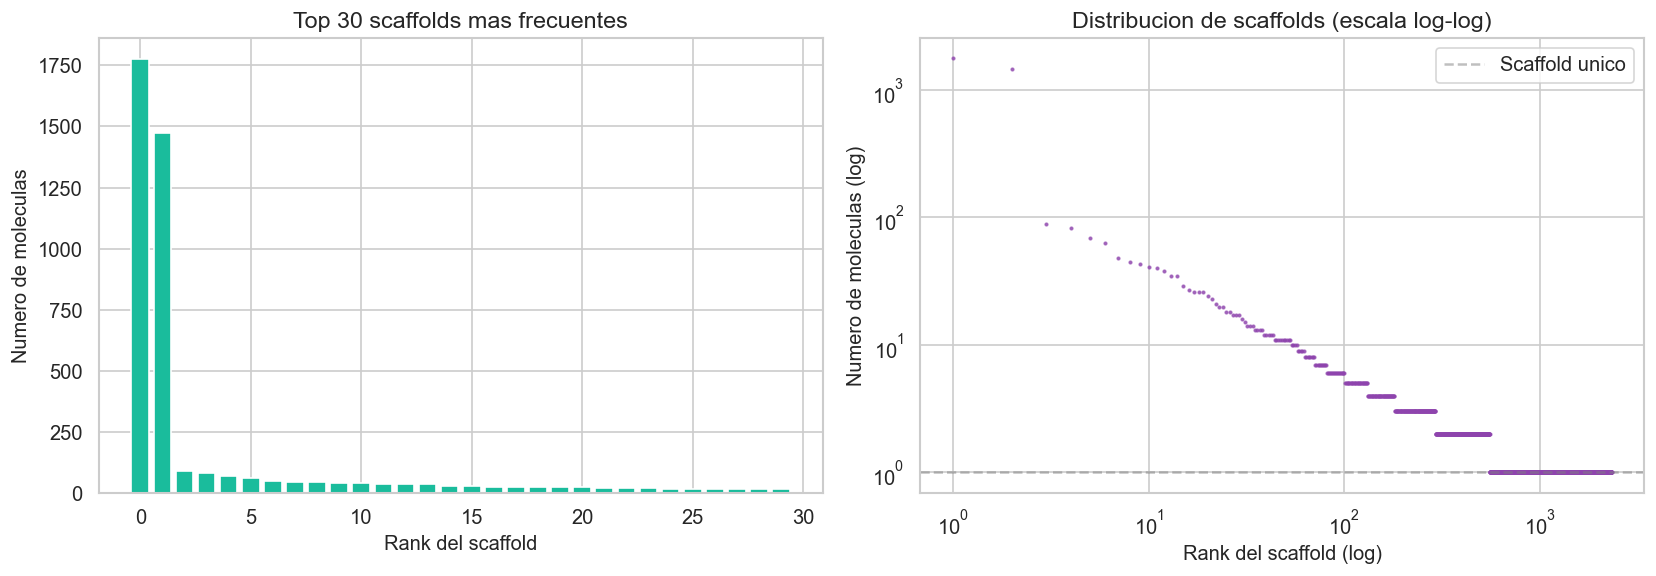

Scaffolds con una sola molecula (singletons): 1772 (76.2%)
Scaffolds con 10+ moleculas: 57
Top-10 scaffolds cubren: 3730 moleculas (47.7%)


In [40]:
# Distribucion del tamano de scaffolds (cuantas moleculas por scaffold)
scaffold_sizes = sorted(scaffold_counts.values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: top 30 scaffolds
top_n = 30
axes[0].bar(range(top_n), scaffold_sizes[:top_n], color="#1abc9c", edgecolor="white")
axes[0].set_xlabel("Rank del scaffold")
axes[0].set_ylabel("Numero de moleculas")
axes[0].set_title(f"Top {top_n} scaffolds mas frecuentes")

# Panel derecho: distribucion log-log (cola larga)
axes[1].loglog(range(1, len(scaffold_sizes) + 1), scaffold_sizes, ".", 
               color="#8e44ad", markersize=3, alpha=0.7)
axes[1].set_xlabel("Rank del scaffold (log)")
axes[1].set_ylabel("Numero de moleculas (log)")
axes[1].set_title("Distribucion de scaffolds (escala log-log)")
axes[1].axhline(y=1, color="gray", linestyle="--", alpha=0.5, label="Scaffold unico")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "13_scaffolds.png", dpi=150, bbox_inches="tight")
plt.show()

singletons = sum(1 for s in scaffold_sizes if s == 1)
print(f"Scaffolds con una sola molecula (singletons): {singletons} ({100*singletons/n_scaffolds:.1f}%)")
print(f"Scaffolds con 10+ moleculas: {sum(1 for s in scaffold_sizes if s >= 10)}")
print(f"Top-10 scaffolds cubren: {sum(scaffold_sizes[:10])} moleculas ({100*sum(scaffold_sizes[:10])/len(smiles_validos):.1f}%)")

## 9. Calidad del scaffold split

El scaffold split separa moleculas por su estructura central, asegurando que moleculas
con el mismo esqueleto esten siempre en el mismo conjunto (train, val, o test).

Para que el split sea bueno, las distribuciones de propiedades deberian ser similares
entre train, val y test, sin sesgos obvios.

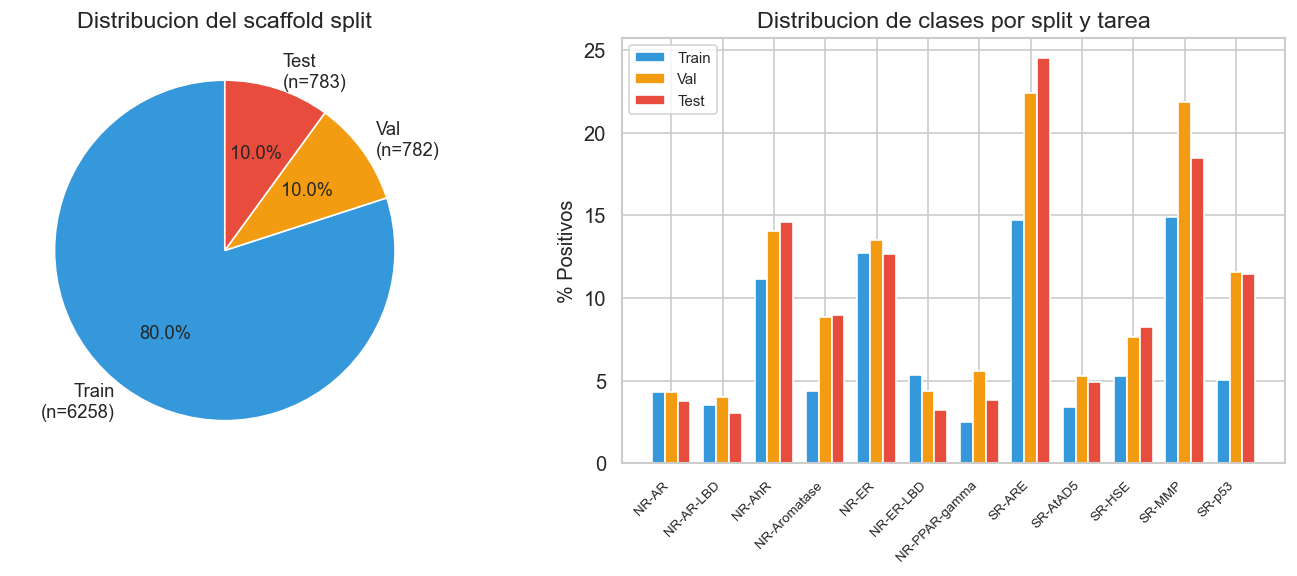

In [41]:
# Proporcion de cada split
split_counts = Counter(split_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
labels_pie = ["Train", "Val", "Test"]
sizes_pie = [split_counts["train"], split_counts["val"], split_counts["test"]]
colors_pie = ["#3498db", "#f39c12", "#e74c3c"]
axes[0].pie(
    sizes_pie,
    labels=[f"{l}\n(n={s})" for l, s in zip(labels_pie, sizes_pie)],
    colors=colors_pie,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 11},
)
axes[0].set_title("Distribucion del scaffold split")

# Porcentaje de positivos por split y tarea
pct_by_split = {}
for split_name in ["train", "val", "test"]:
    y_s = data[split_name]["y"]
    m_s = data[split_name]["mask"]
    pcts = []
    for t in range(N_TASKS):
        v = m_s[:, t].astype(bool)
        if v.sum() > 0:
            pcts.append(100.0 * y_s[v, t].sum() / v.sum())
        else:
            pcts.append(0.0)
    pct_by_split[split_name] = pcts

x = np.arange(N_TASKS)
ancho = 0.25
axes[1].bar(x - ancho, pct_by_split["train"], ancho, label="Train", color="#3498db")
axes[1].bar(x, pct_by_split["val"], ancho, label="Val", color="#f39c12")
axes[1].bar(x + ancho, pct_by_split["test"], ancho, label="Test", color="#e74c3c")
axes[1].set_xticks(x)
axes[1].set_xticklabels(TASK_NAMES, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("% Positivos")
axes[1].set_title("Distribucion de clases por split y tarea")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "14_calidad_split.png", dpi=150, bbox_inches="tight")
plt.show()

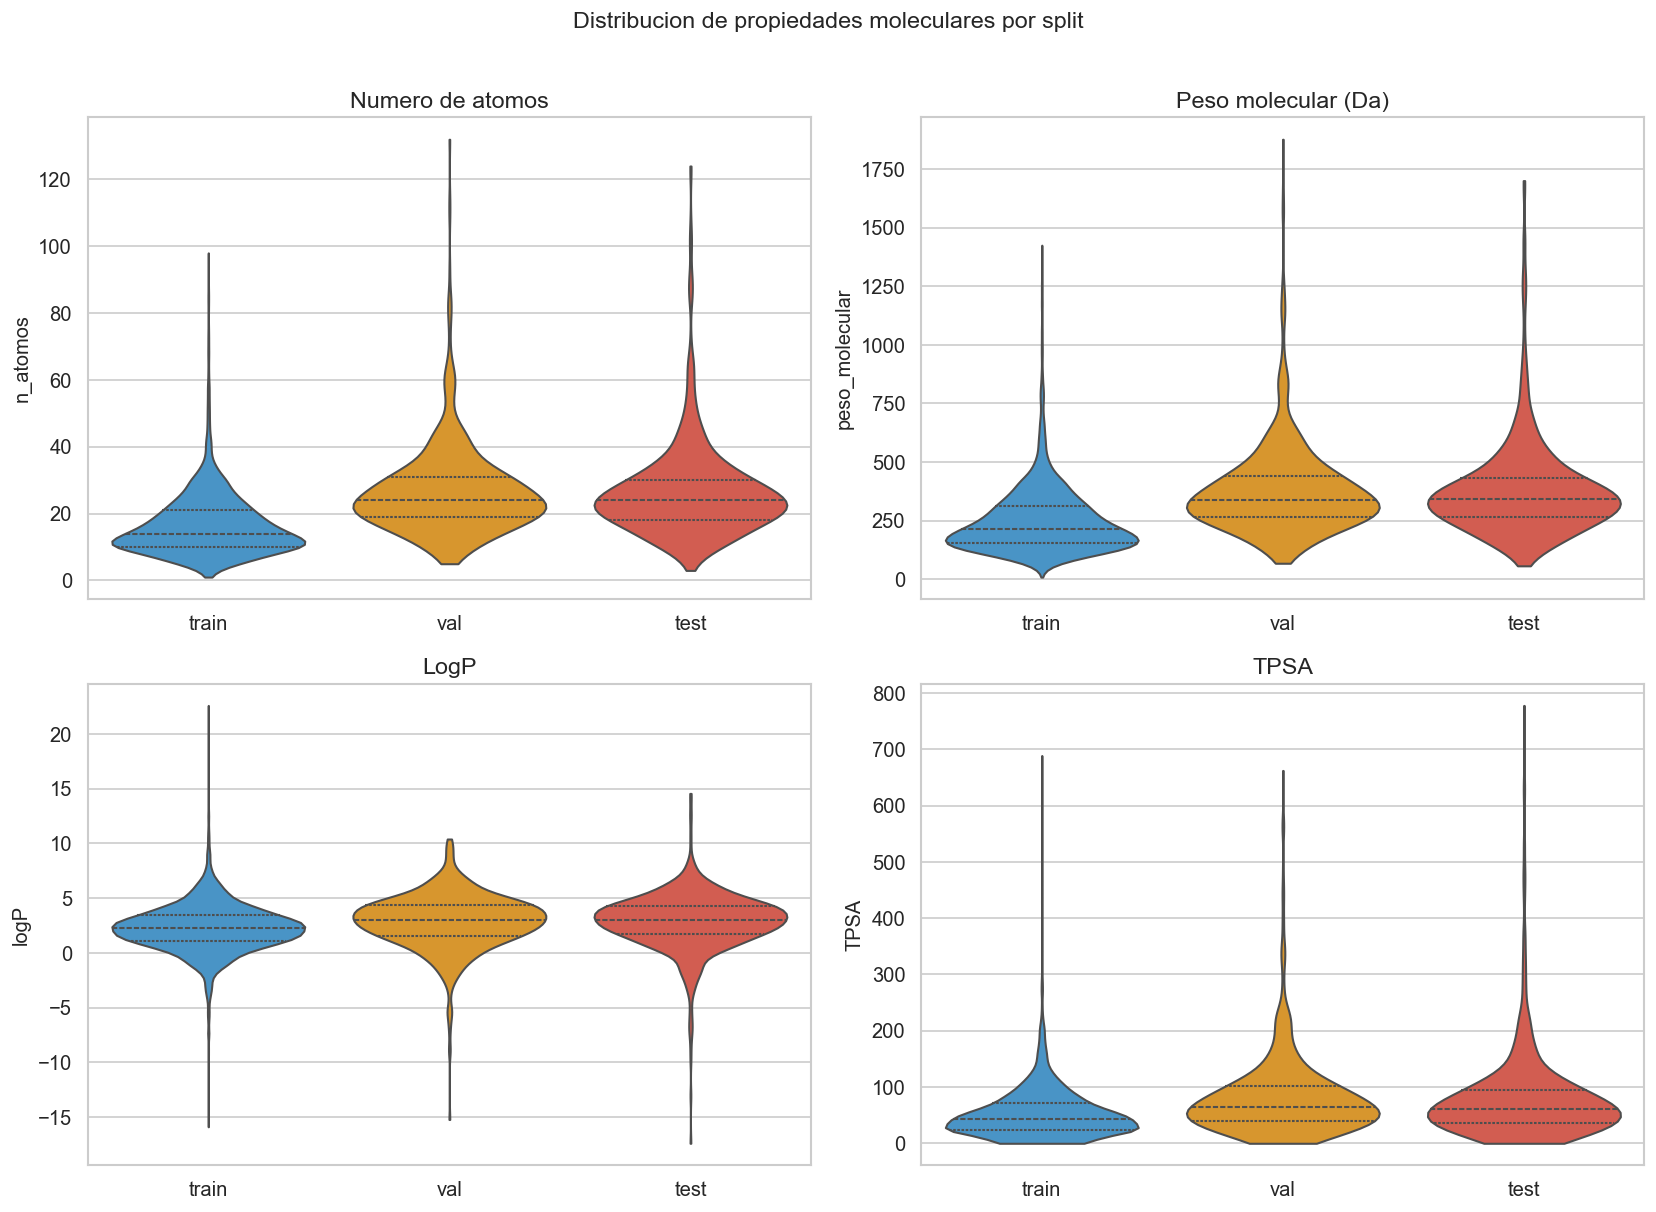

Si las distribuciones son similares entre splits, el scaffold split
no introdujo sesgos sistematicos en propiedades fisicoquimicas.


In [42]:
# Comparar distribuciones de propiedades moleculares entre splits
propiedades_clave = ["n_atomos", "peso_molecular", "logP", "TPSA"]
titulos = ["Numero de atomos", "Peso molecular (Da)", "LogP", "TPSA"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for i, (prop, titulo) in enumerate(zip(propiedades_clave, titulos)):
    sns.violinplot(
        x="split", y=prop, data=df_props,
        order=["train", "val", "test"],
        palette={"train": "#3498db", "val": "#f39c12", "test": "#e74c3c"},
        ax=axes_flat[i],
        inner="quartile",
        cut=0,
    )
    axes_flat[i].set_title(titulo)
    axes_flat[i].set_xlabel("")

plt.suptitle("Distribucion de propiedades moleculares por split", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "15_propiedades_por_split.png", dpi=150, bbox_inches="tight")
plt.show()

print("Si las distribuciones son similares entre splits, el scaffold split")
print("no introdujo sesgos sistematicos en propiedades fisicoquimicas.")

## 10. Propiedades moleculares vs toxicidad

Analizamos si hay relacion entre propiedades fisicoquimicas y la toxicidad.
Esto es relevante porque los modelos baseline (RF, MLP) usan fingerprints que codifican
estas propiedades de forma implicita.

[22:50:05] WARNING: not removing hydrogen atom without neighbors
[22:50:07] WARNING: not removing hydrogen atom without neighbors
[22:50:09] WARNING: not removing hydrogen atom without neighbors
[22:50:11] WARNING: not removing hydrogen atom without neighbors


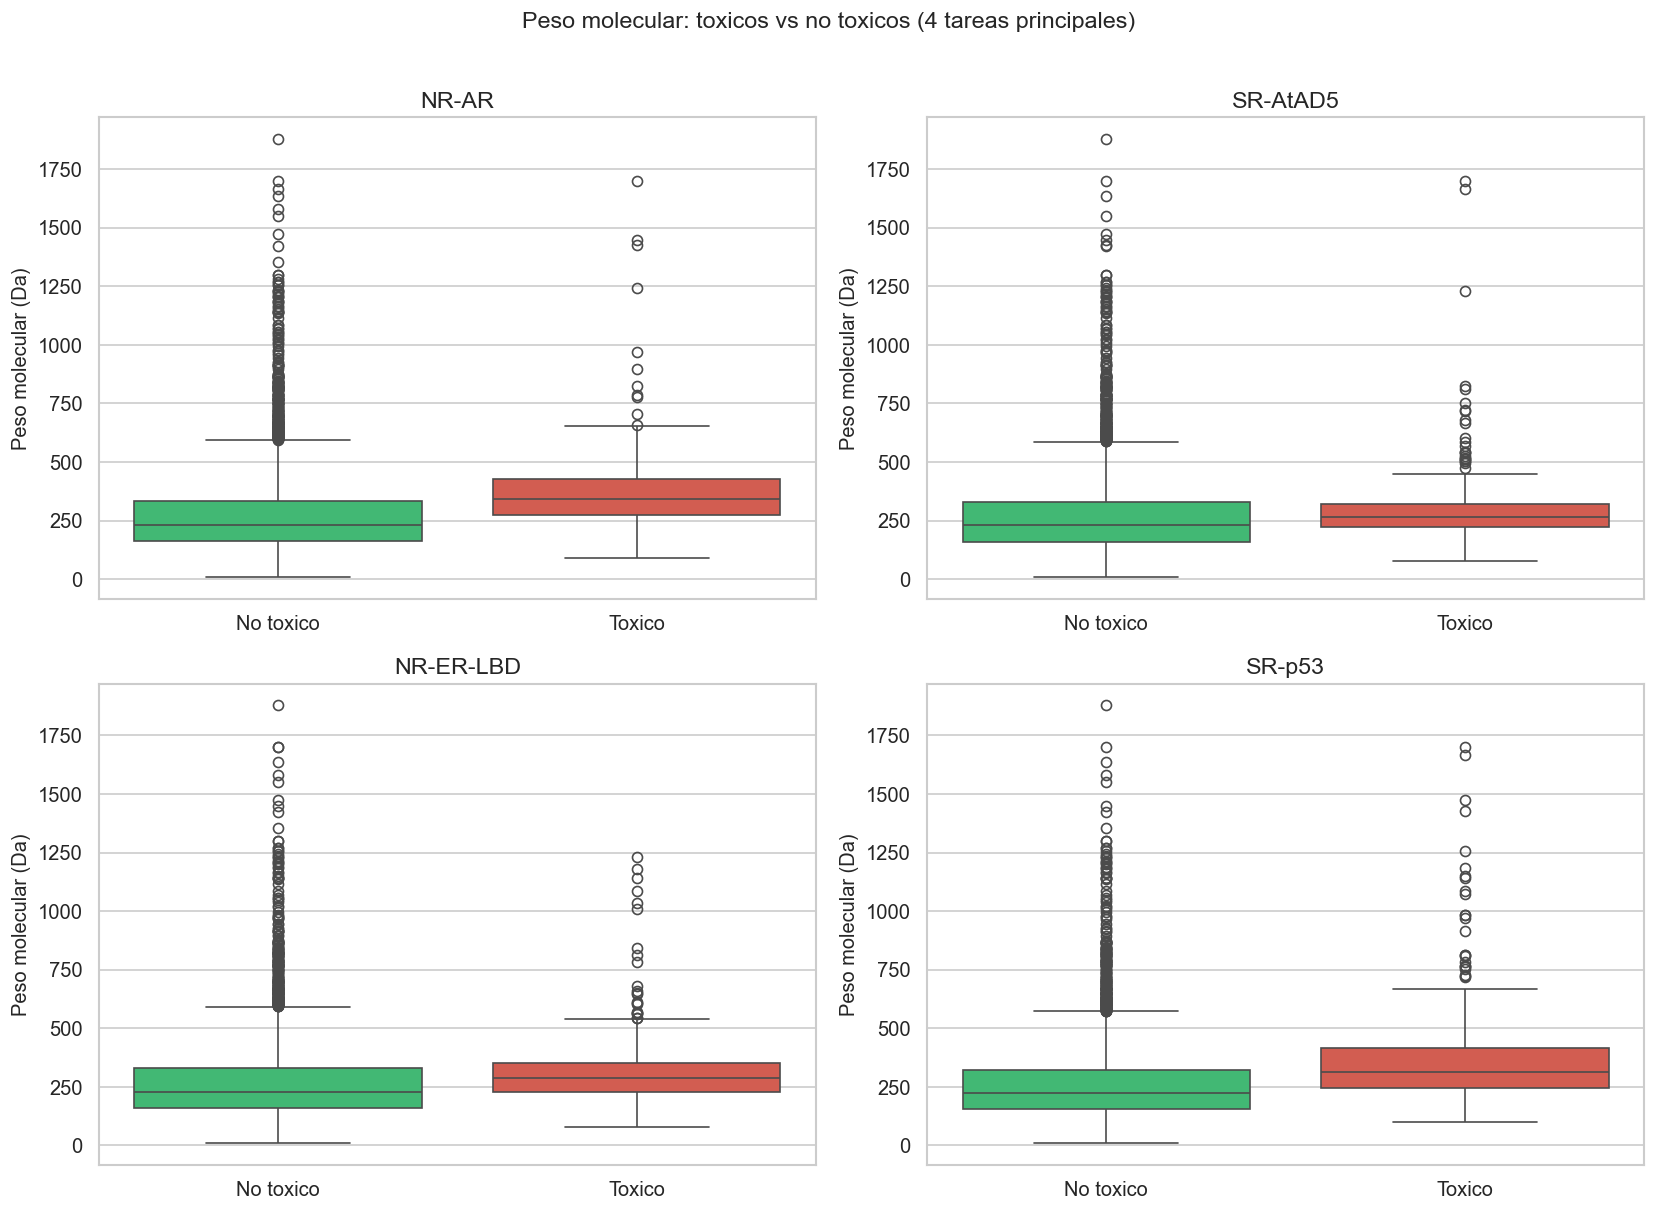

In [43]:
# Para las 4 tareas con mas datos, comparar propiedades entre toxicos y no toxicos
tareas_top = sorted(
    range(N_TASKS),
    key=lambda t: all_mask[:, t].sum(),
    reverse=True,
)[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for idx_ax, t in enumerate(tareas_top):
    name = TASK_NAMES[t]
    # Obtener etiquetas para moleculas validas
    # Necesitamos mapear df_props a all_y
    mask_t = all_mask[:, t].astype(bool)

    # Crear columna de toxicidad para esta tarea (solo moleculas con props calculadas)
    # Indices de smiles_validos corresponden a posiciones en all_smiles donde mol != None
    etiquetas = []
    pesos = []
    idx_original = 0
    for i, smi in enumerate(all_smiles):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        if mask_t[i]:
            etiquetas.append("Toxico" if all_y[i, t] == 1 else "No toxico")
        else:
            etiquetas.append("Sin dato")
        pesos.append(df_props.iloc[idx_original]["peso_molecular"])
        idx_original += 1

    df_tox = df_props.copy()
    df_tox["toxicidad"] = etiquetas
    df_filtrado = df_tox[df_tox["toxicidad"] != "Sin dato"]

    sns.boxplot(
        x="toxicidad", y="peso_molecular", data=df_filtrado,
        palette={"Toxico": "#e74c3c", "No toxico": "#2ecc71"},
        ax=axes_flat[idx_ax],
    )
    axes_flat[idx_ax].set_title(f"{name}")
    axes_flat[idx_ax].set_xlabel("")
    axes_flat[idx_ax].set_ylabel("Peso molecular (Da)")

plt.suptitle("Peso molecular: toxicos vs no toxicos (4 tareas principales)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "16_peso_vs_toxicidad.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Resumen y conclusiones del EDA

### Hallazgos principales

1. **Desbalance severo**: La mayoria de tareas tiene <10% de positivos. Las tareas NR (receptores
   nucleares) son especialmente desbalanceadas (~2-5%). Esto justifica usar `pos_weight` en la
   funcion de perdida y evaluar con AUC-ROC en vez de accuracy.

2. **Datos faltantes significativos**: Varias tareas tienen >20% de NaN. El patron de faltantes
   no es aleatorio — hay grupos de tareas que se midieron juntas. `MaskedBCELoss` es esencial.

3. **Multi-toxicidad**: Muchas moleculas son toxicas en multiples vias simultaneamente,
   especialmente las combinaciones NR-AR/NR-AR-LBD y NR-ER/NR-ER-LBD (que miden la misma
   diana con ensayos diferentes).

4. **Espacio quimico**: Las moleculas son relativamente pequenas (mediana ~20-25 atomos),
   la mayoria cumple la regla de Lipinski, y dominan C, N, O como tipos de atomos.

5. **Diversidad de scaffolds**: Hay muchos scaffolds unicos pero con distribucion de cola larga
   (pocos scaffolds representan muchas moleculas). El scaffold split es la eleccion correcta.

6. **Calidad del split**: Las distribuciones de propiedades son razonablemente similares entre
   train/val/test, aunque pueden haber diferencias en las colas por la naturaleza del scaffold split.

### Implicaciones para el modelo

- **Arquitectura**: Las moleculas son pequenas → 3-5 capas GIN son suficientes
- **Perdida**: MaskedBCELoss + pos_weight son necesarios por desbalance y NaN
- **Evaluacion**: AUC-ROC por tarea + promedio; reportar tambien AUPRC
- **XAI**: Los atomos C, N, O dominan → las explicaciones deben distinguir *que* C/N/O
  importa, no solo que son los mas comunes

In [44]:
# Listado de todos los graficos generados
print("Graficos guardados en:", OUT_DIR)
print()
for f in sorted(OUT_DIR.glob("*.png")):
    print(f"  {f.name}")

Graficos guardados en: c:\Users\mateo\Desktop\JIC2026\outputs\eda

  01_distribucion_clases.png
  02_datos_faltantes.png
  03_patron_faltantes_heatmap.png
  04_correlacion_faltantes.png
  05_multi_etiqueta.png
  06_coocurrencia_toxicidad.png
  07_correlacion_tareas_cluster.png
  08_propiedades_moleculares.png
  09_lipinski.png
  10_espacio_quimico.png
  11_atomos_y_enlaces.png
  12_anillos.png
  13_scaffolds.png
  14_calidad_split.png
  15_propiedades_por_split.png
  16_peso_vs_toxicidad.png
